Etape 2 : Les Statistiques Descriptives

In [201]:
from google.colab import files

fichier = files.upload()

Saving world-data-2023.csv to world-data-2023 (4).csv


In [202]:
import os

print("Répertoire courant :", os.getcwd())
print("Fichiers :", os.listdir())

Répertoire courant : /content
Fichiers : ['.config', 'world-data-2023 (2).csv', 'world-data-2023-clean (6).csv', 'world-data-2023-clean (4).csv', 'world-data-2023-clean.csv', 'world-data-2023-clean (1).csv', 'world-data-2023-clean (5).csv', 'world-data-2023 (1).csv', 'world-data-2023-clean (3).csv', 'world-data-2023-clean (2).csv', 'world-data-2023 (3).csv', 'world-data-2023.csv', 'world-data-2023 (4).csv', 'sample_data']


In [203]:
import pandas as pd
import seaborn as sns
import matplotlib

print(pd.__version__)
print(sns.__version__)
print(matplotlib.__version__)
df = pd.read_csv("world-data-2023-clean.csv")

2.2.2
0.13.2
3.10.0


1. Dimensions du dataset

In [204]:
# Nombre de lignes et de colonnes
df.shape

(107, 35)

In [206]:
import pandas as pd

# Chargement du fichier brut
df = pd.read_csv("world-data-2023.csv")

# Copie du dataset
df_clean = df.copy()

# Nettoyage des espaces dans les colonnes de type texte
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Colonnes contenant des valeurs numériques stockées comme texte
numeric_columns = [
    "GDP",
    "Population",
    "Density\n(P/Km2)",
    "Agricultural Land( %)",
    "Land Area(Km2)",
    "Armed Forces size",
    "Co2-Emissions",
    "CPI",
    "CPI Change (%)",
    "Forested Area (%)",
    "Gasoline Price",
    "Gross primary education enrollment (%)",
    "Gross tertiary education enrollment (%)",
    "Minimum wage",
    "Out of pocket health expenditure",
    "Population: Labor force participation (%)",
    "Tax revenue (%)",
    "Total tax rate",
    "Unemployment rate",
    "Urban_population"
]

# Conversion en numérique
for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.replace(" km2", "", regex=False)
            .str.strip()
        )

        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Remplacement des valeurs manquantes des colonnes numériques par la médiane
numeric_cols = df_clean.select_dtypes(include="number").columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Vérification
print(df_clean.info())
print(df_clean.isna().sum())

# Sauvegarde
df_clean.to_csv("world-data-2023-clean.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    int64  
 2   Abbreviation                               195 non-null    object 
 3   Agricultural Land( %)                      195 non-null    float64
 4   Land Area(Km2)                             195 non-null    float64
 5   Armed Forces size                          195 non-null    float64
 6   Birth Rate                                 195 non-null    float64
 7   Calling Code                               195 non-null    float64
 8   Capital/Major City                         195 non-null    object 
 9   Co2-Emissions                              195 non-null    float64
 10  CPI                       

In [207]:
print(df_clean.shape)

(195, 35)


In [208]:
print(df_clean["GDP"].isna().sum())

0


In [209]:
print(df_clean.info())
print(df_clean.describe())
print(df_clean.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    int64  
 2   Abbreviation                               195 non-null    object 
 3   Agricultural Land( %)                      195 non-null    float64
 4   Land Area(Km2)                             195 non-null    float64
 5   Armed Forces size                          195 non-null    float64
 6   Birth Rate                                 195 non-null    float64
 7   Calling Code                               195 non-null    float64
 8   Capital/Major City                         195 non-null    object 
 9   Co2-Emissions                              195 non-null    float64
 10  CPI                       

3. Description statistique des variables numériques

In [210]:
# Statistiques descriptives
df.describe()

,Birth Rate,Calling Code,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Latitude,Longitude
count,189.000000,194.000000,188.000000,189.000000,187.000000,181.000000,188.000000,194.000000,194.000000
mean,20.214974,360.546392,2.698138,21.332804,72.279679,160.392265,1.839840,19.092351,20.232434
std,9.945774,323.236419,1.282267,19.548058,7.483661,233.502024,1.684261,23.961779,66.716110
min,5.900000,1.000000,0.980000,1.400000,52.800000,2.000000,0.010000,-40.900557,-175.198242
25%,11.300000,82.500000,1.705000,6.000000,67.000000,13.000000,0.332500,4.544175,-7.941496
50%,17.950000,255.500000,2.245000,14.000000,73.200000,53.000000,1.460000,17.273849,20.972652
75%,28.750000,506.750000,3.597500,32.700000,77.500000,186.000000,2.935000,40.124603,48.281523
max,46.080000,1876.000000,6.910000,84.500000,85.400000,1150.000000,8.420000,64.963051,178.065032


Cette commande affiche notamment :

le nombre de valeurs (count) ;
la moyenne (mean) ;
l'écart-type (std) ;
la valeur minimale (min) ;
les quartiles (25 %, 50 %, 75 %) ;
la valeur maximale (max).

4. Description des variables catégorielles

In [211]:
# Variables de type texte
df.describe(include="object")

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Capital/Major City,Co2-Emissions,CPI,CPI Change (%),...,Largest city,Minimum wage,Official language,Out of pocket health expenditure,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
count,195,195,188,188,194,171,192,188,178,179,...,189,150,190,188,194,176,169,183,176,190
unique,195,137,188,168,194,105,192,184,175,86,...,188,114,76,160,194,145,119,156,164,190
top,Afghanistan,25,AF,17.40%,"652,230","2,000",Kabul,"28,284",106.58,1.80%,...,S����,$2.00,English,40.50%,"38,041,754",65.10%,19.50%,36.60%,4.59%,"9,797,273"
freq,1,7,1,3,1,7,1,2,2,7,...,2,3,31,3,1,3,4,4,3,1


5. Moyenne des variables numériques

In [213]:
df.mean(numeric_only=True)

,0
Birth Rate,20.214974
Calling Code,360.546392
Fertility Rate,2.698138
Infant mortality,21.332804
Life expectancy,72.279679
Maternal mortality ratio,160.392265
Physicians per thousand,1.839840
Latitude,19.092351
Longitude,20.232434


6. Médiane

In [214]:
df.median(numeric_only=True)

,0
Birth Rate,17.950000
Calling Code,255.500000
Fertility Rate,2.245000
Infant mortality,14.000000
Life expectancy,73.200000
Maternal mortality ratio,53.000000
Physicians per thousand,1.460000
Latitude,17.273849
Longitude,20.972652


7. Écart-type

In [215]:
df.std(numeric_only=True)

,0
Birth Rate,9.945774
Calling Code,323.236419
Fertility Rate,1.282267
Infant mortality,19.548058
Life expectancy,7.483661
Maternal mortality ratio,233.502024
Physicians per thousand,1.684261
Latitude,23.961779
Longitude,66.716110


8. Valeurs minimales
9. Valeurs maximales

In [216]:
df.min(numeric_only=True)
df.max(numeric_only=True)

,0
Birth Rate,46.080000
Calling Code,1876.000000
Fertility Rate,6.910000
Infant mortality,84.500000
Life expectancy,85.400000
Maternal mortality ratio,1150.000000
Physicians per thousand,8.420000
Latitude,64.963051
Longitude,178.065032


10. Quartiles

In [217]:
df.quantile([0.25, 0.50, 0.75], numeric_only=True)

,Birth Rate,Calling Code,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Latitude,Longitude
0.25,11.30,82.50,1.7050,6.0,67.0,13.0,0.3325,4.544175,-7.941496
0.50,17.95,255.50,2.2450,14.0,73.2,53.0,1.4600,17.273849,20.972652
0.75,28.75,506.75,3.5975,32.7,77.5,186.0,2.9350,40.124603,48.281523


11. Vérifier les valeurs manquantes

In [218]:
df.isnull().sum()

,0
Country,0
Density\n(P/Km2),0
Abbreviation,7
Agricultural Land( %),7
Land Area(Km2),1
Armed Forces size,24
Birth Rate,6
Calling Code,1
Capital/Major City,3
Co2-Emissions,7


12. Vérifier les doublons

In [219]:
df.duplicated().sum()

np.int64(0)

13. Corrélations entre les variables numériques

In [221]:
df.corr(numeric_only=True)

,Birth Rate,Calling Code,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Latitude,Longitude
Birth Rate,1.000000,0.072071,0.981069,0.867456,-0.874747,0.768078,-0.740290,-0.502965,0.039247
Calling Code,0.072071,1.000000,0.028379,-0.030603,-0.034624,-0.130962,-0.041556,0.012973,0.194236
Fertility Rate,0.981069,0.028379,1.000000,0.852653,-0.849153,0.779460,-0.683172,-0.457999,0.034218
Infant mortality,0.867456,-0.030603,0.852653,1.000000,-0.924675,0.874135,-0.691382,-0.436380,0.037578
Life expectancy,-0.874747,-0.034624,-0.849153,-0.924675,1.000000,-0.831797,0.703740,0.472759,-0.072483
Maternal mortality ratio,0.768078,-0.130962,0.779460,0.874135,-0.831797,1.000000,-0.582919,-0.330127,-0.015930
Physicians per thousand,-0.740290,-0.041556,-0.683172,-0.691382,0.703740,-0.582919,1.000000,0.526565,-0.064380
Latitude,-0.502965,0.012973,-0.457999,-0.436380,0.472759,-0.330127,0.526565,1.000000,0.013635
Longitude,0.039247,0.194236,0.034218,0.037578,-0.072483,-0.015930,-0.064380,0.013635,1.000000


Cette étape sera très utile avant de réaliser une heatmap.

3.
Les statistiques descriptives permettent d'obtenir une première vision du dataset nettoyé. Elles résument les principales caractéristiques des variables numériques et facilitent l'identification des tendances générales, des dispersions et des valeurs extrêmes.

Cette étape a pour objectif de :

vérifier la cohérence des données après le nettoyage ;
observer la répartition des principales variables (population, PIB, espérance de vie, taux de chômage, etc.) ;
comparer les ordres de grandeur des indicateurs ;
identifier les éventuelles valeurs atypiques qui pourraient influencer l'analyse.
Pour réaliser cette analyse, nous utilisons notamment les fonctions describe(), mean(), median(), min(), max() et std(), qui fournissent des indicateurs tels que :

la moyenne : valeur moyenne de la variable ;
la médiane : valeur centrale, moins influencée par les valeurs extrêmes ;
l'écart-type : mesure de la dispersion des données autour de la moyenne ;
les valeurs minimale et maximale : permettent d'identifier les amplitudes des variables ;
les quartiles : donnent une vision de la répartition des données.
L'analyse de ces indicateurs constitue une première étape indispensable avant les analyses de corrélation et les visualisations, car elle permet de mieux comprendre la structure du jeu de données et d'interpréter les résultats obtenus par la suite.

✅ Étape 3 – Analyse exploratoire (Python)

3.1 Corrélations entre les variables

Objectif : identifier les relations entre les indicateurs économiques et sociaux.

In [223]:
corr = df.corr(numeric_only=True)
corr

,Birth Rate,Calling Code,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Latitude,Longitude
Birth Rate,1.000000,0.072071,0.981069,0.867456,-0.874747,0.768078,-0.740290,-0.502965,0.039247
Calling Code,0.072071,1.000000,0.028379,-0.030603,-0.034624,-0.130962,-0.041556,0.012973,0.194236
Fertility Rate,0.981069,0.028379,1.000000,0.852653,-0.849153,0.779460,-0.683172,-0.457999,0.034218
Infant mortality,0.867456,-0.030603,0.852653,1.000000,-0.924675,0.874135,-0.691382,-0.436380,0.037578
Life expectancy,-0.874747,-0.034624,-0.849153,-0.924675,1.000000,-0.831797,0.703740,0.472759,-0.072483
Maternal mortality ratio,0.768078,-0.130962,0.779460,0.874135,-0.831797,1.000000,-0.582919,-0.330127,-0.015930
Physicians per thousand,-0.740290,-0.041556,-0.683172,-0.691382,0.703740,-0.582919,1.000000,0.526565,-0.064380
Latitude,-0.502965,0.012973,-0.457999,-0.436380,0.472759,-0.330127,0.526565,1.000000,0.013635
Longitude,0.039247,0.194236,0.034218,0.037578,-0.072483,-0.015930,-0.064380,0.013635,1.000000


la heatmap :

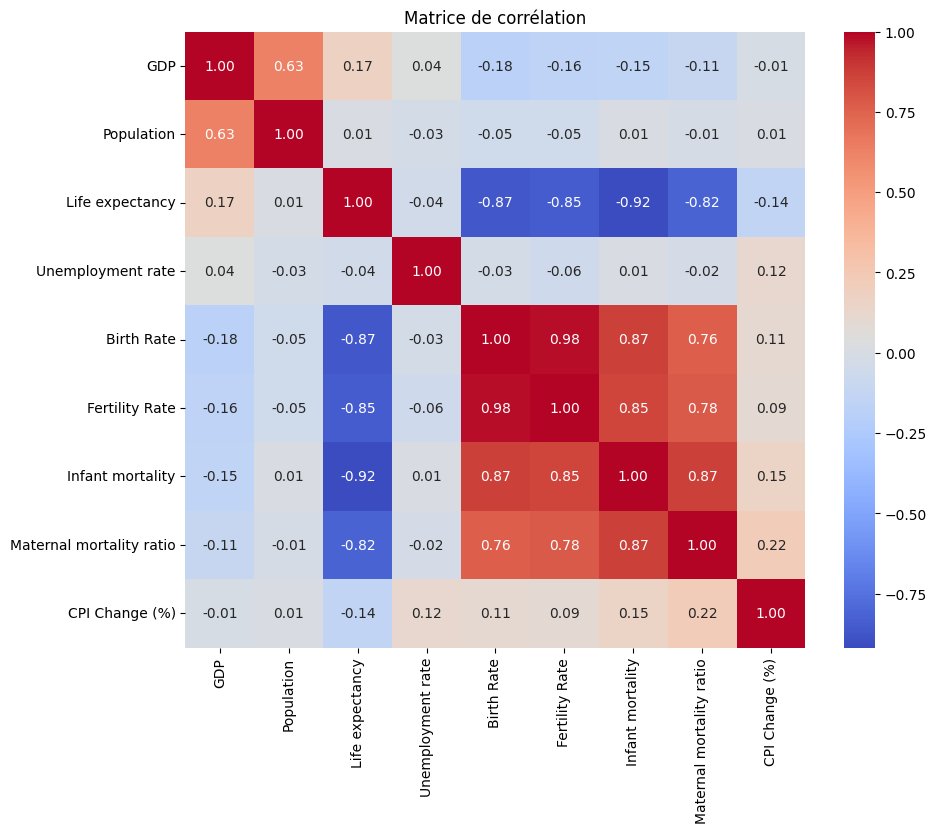

In [228]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean[variables].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()

3.2 Distribution des principales variables

Par exemple le PIB.

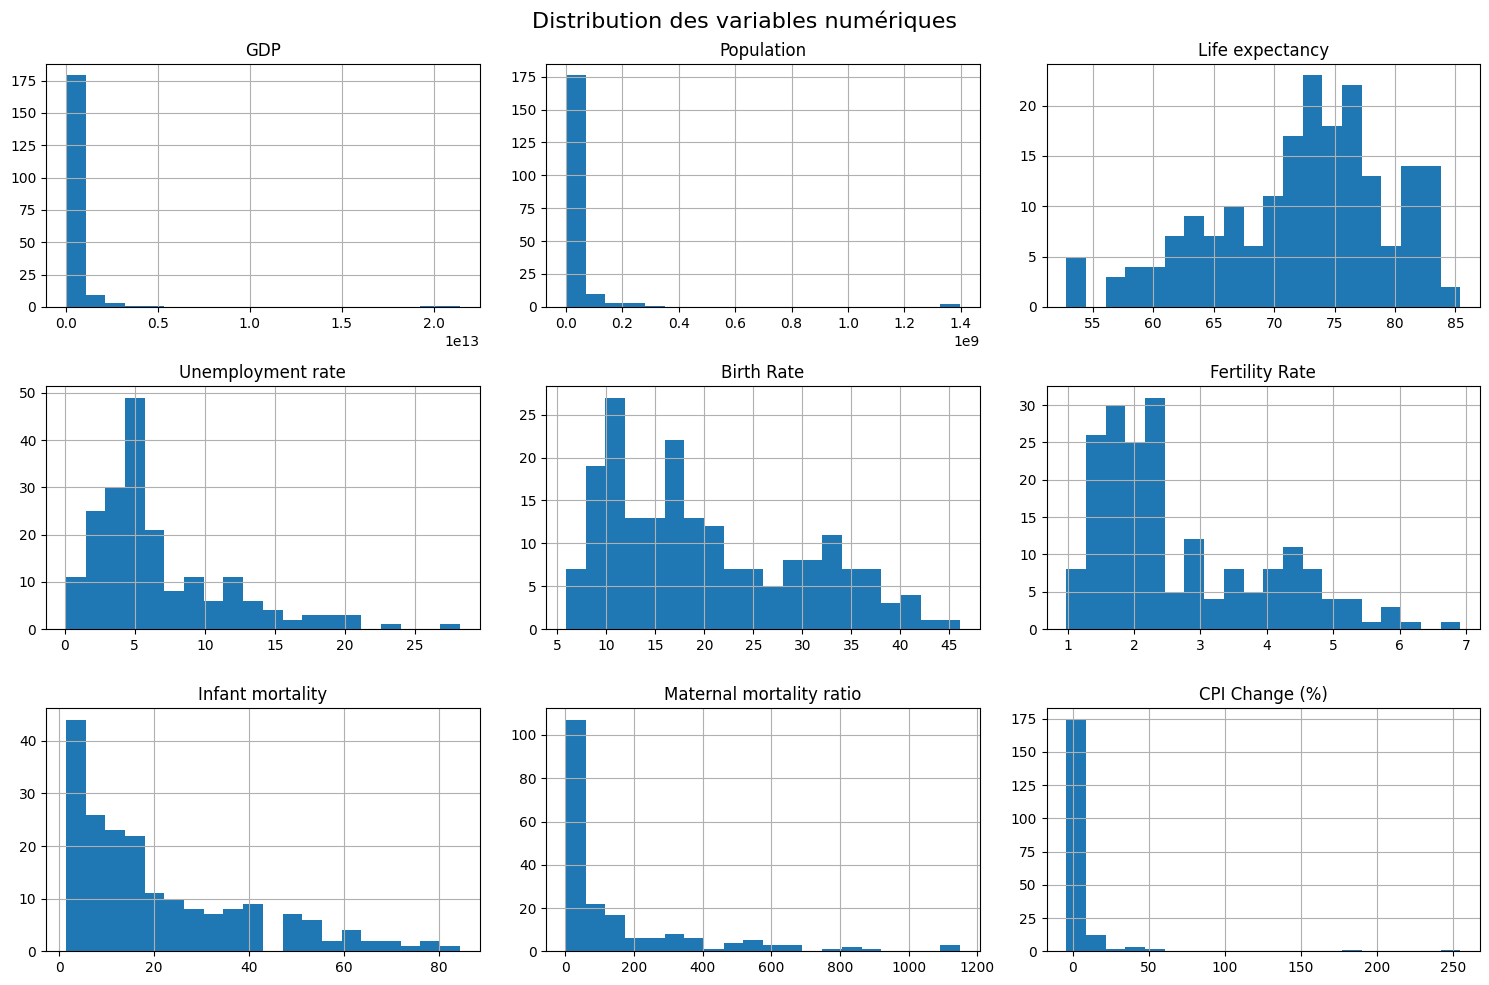

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    "GDP",
    "Population",
    "Life expectancy",
    "Unemployment rate",
    "Birth Rate",
    "Fertility Rate",
    "Infant mortality",
    "Maternal mortality ratio",
    "CPI Change (%)"
]

df_clean[variables].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution des variables numériques", fontsize=16)
plt.tight_layout()
plt.show()

Détection des valeurs extrêmes (Boxplots)

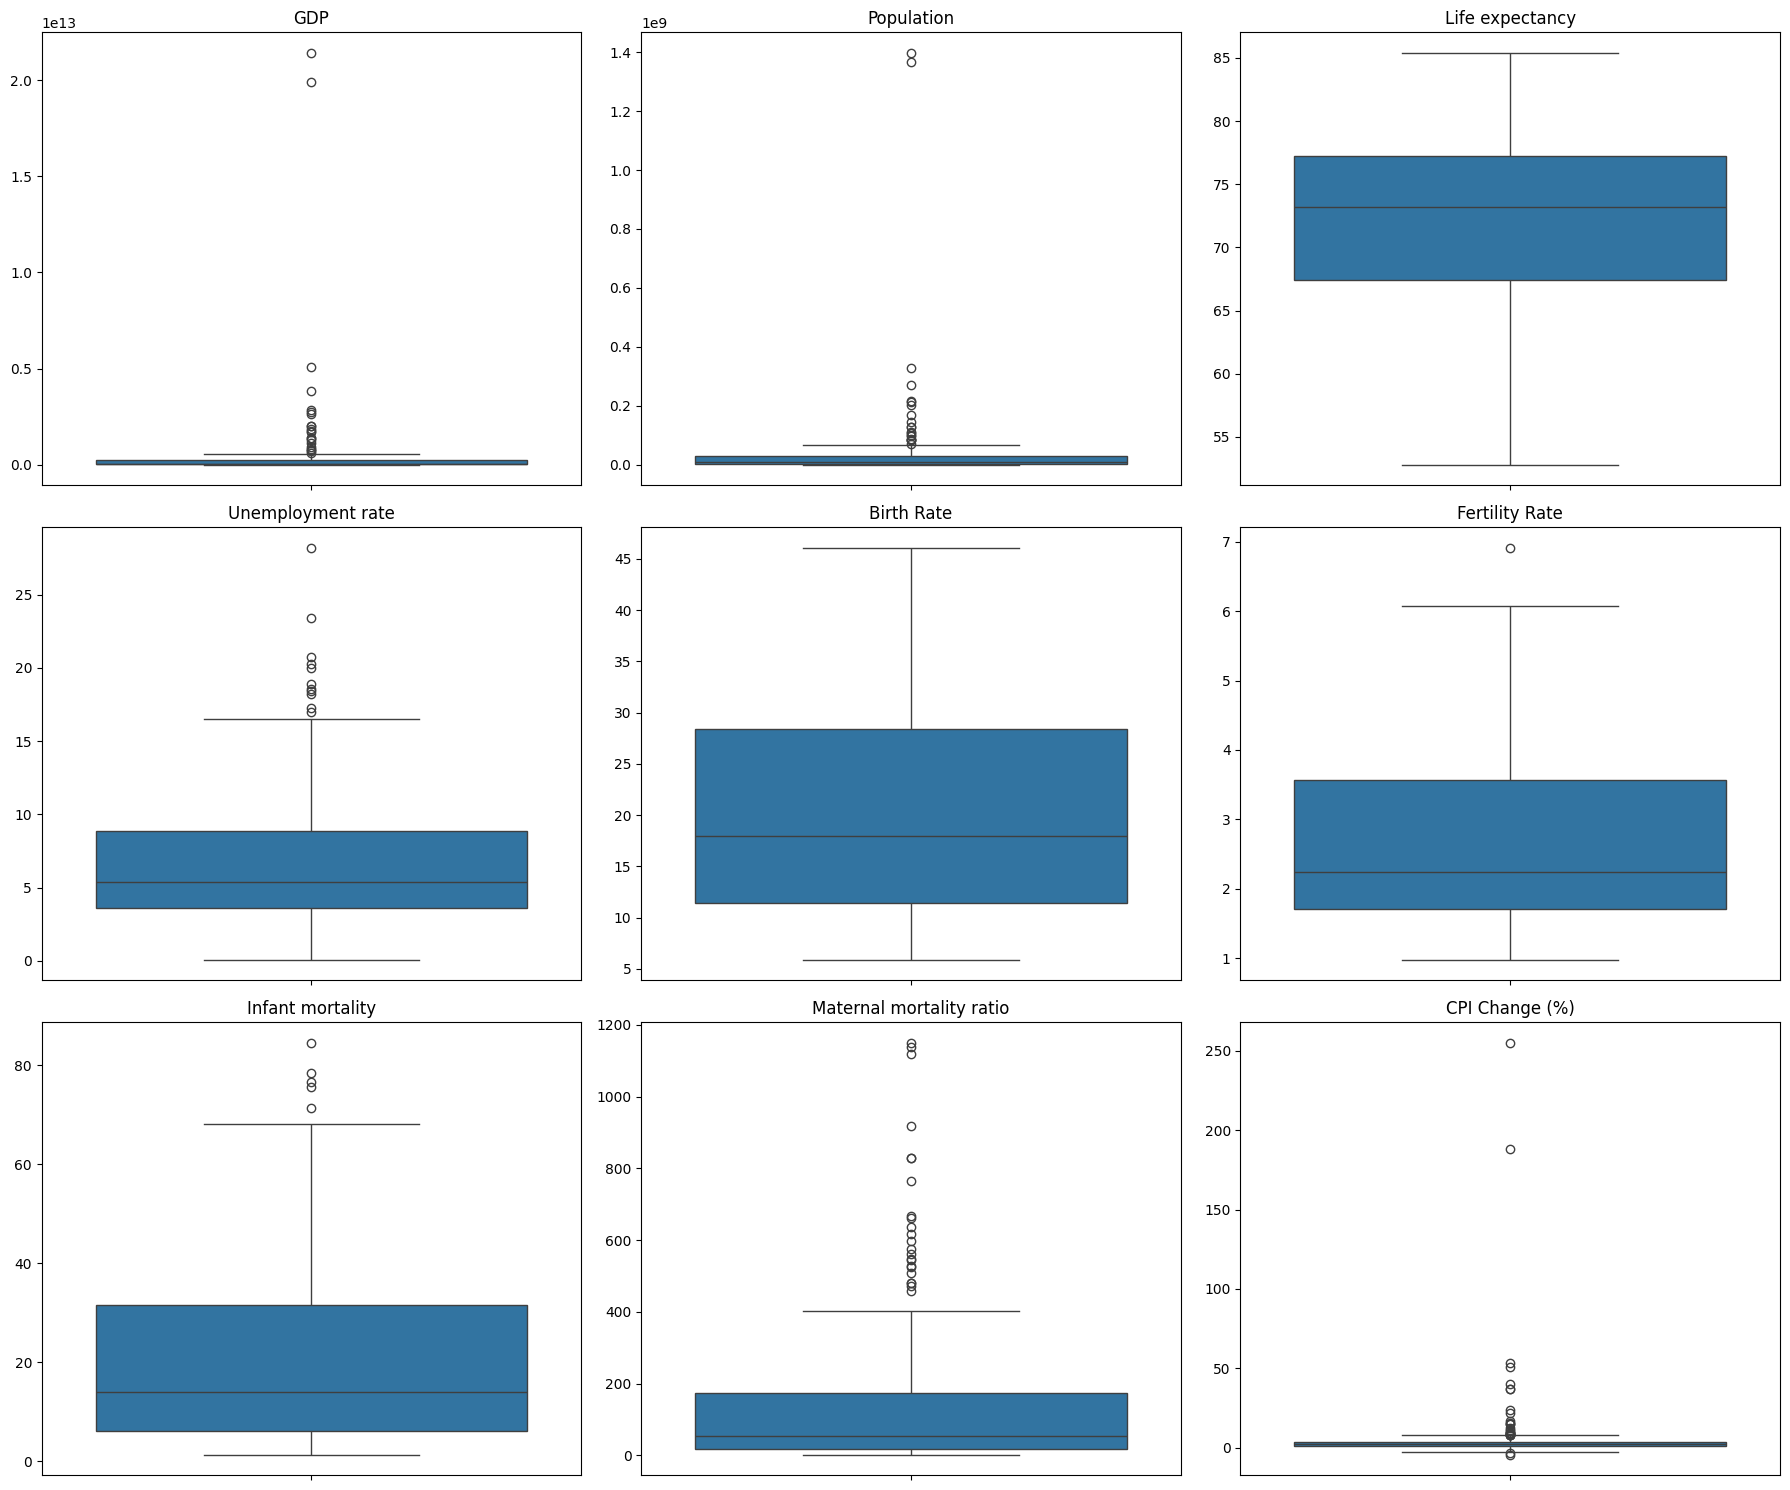

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, variable in enumerate(variables):
    sns.boxplot(y=df_clean[variable], ax=axes[i])
    axes[i].set_title(variable)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

Relations entre les variables (scatterplot)

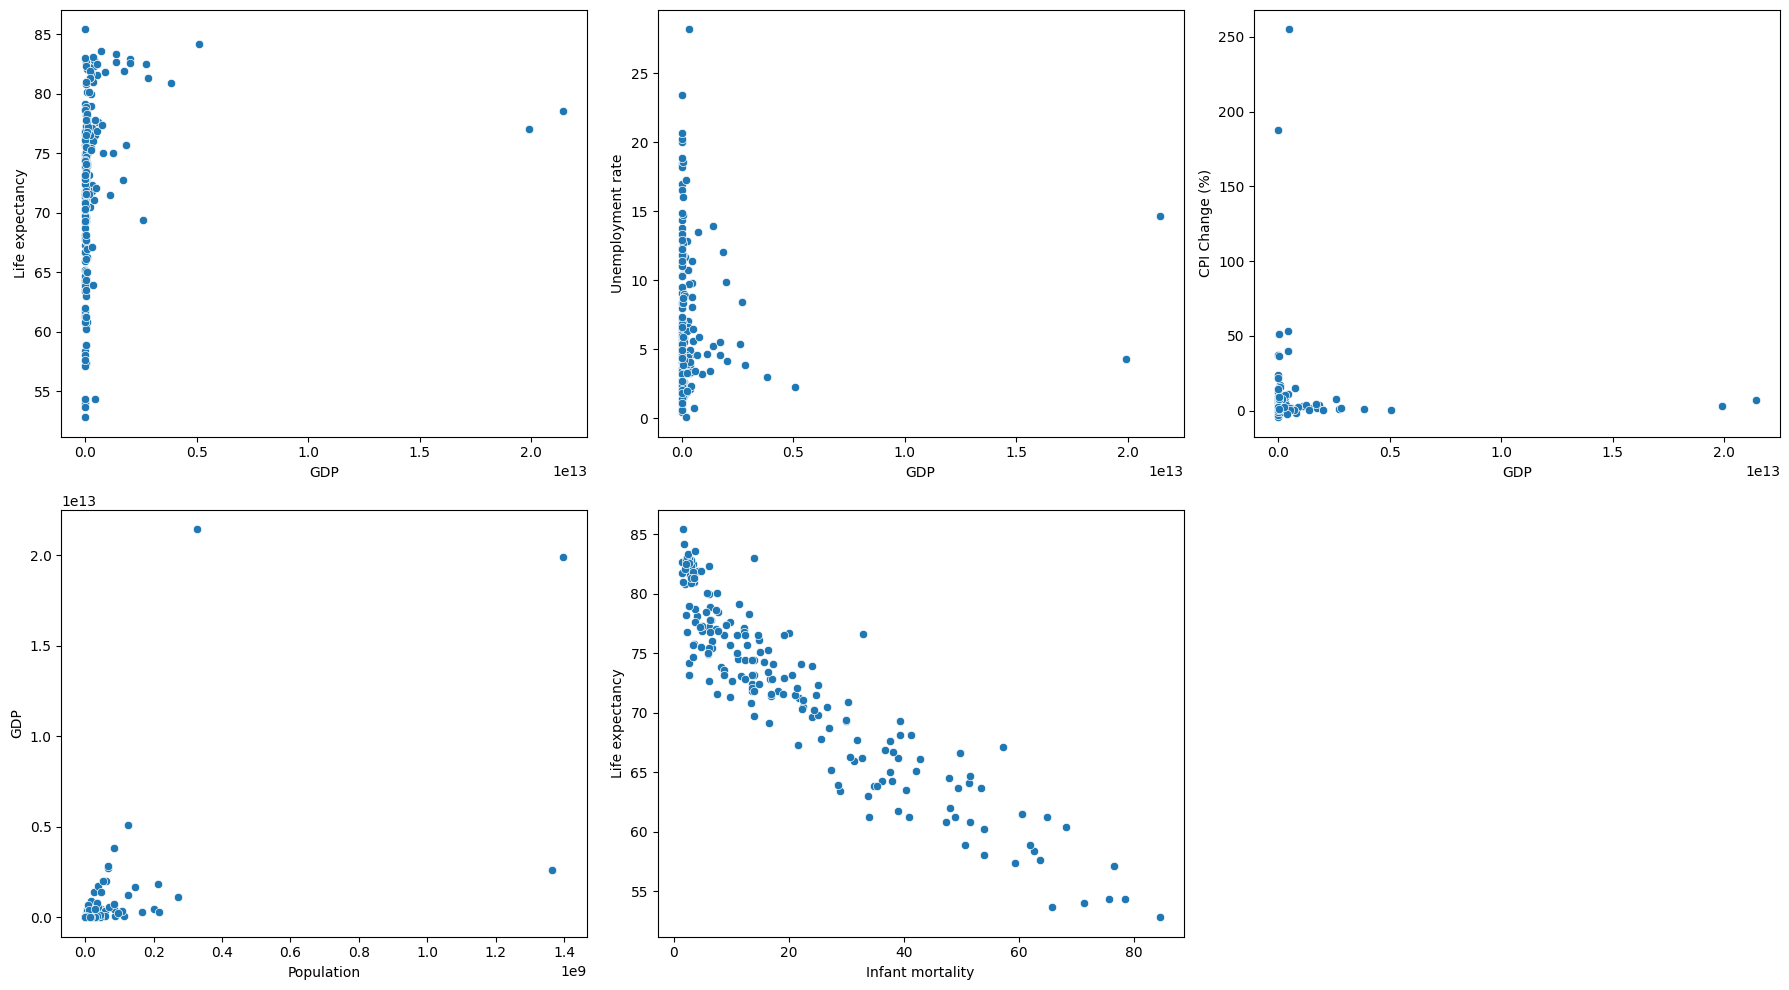

In [229]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sns.scatterplot(data=df_clean, x="GDP", y="Life expectancy", ax=axes[0])

sns.scatterplot(data=df_clean, x="GDP", y="Unemployment rate", ax=axes[1])

sns.scatterplot(data=df_clean, x="GDP", y="CPI Change (%)", ax=axes[2])

sns.scatterplot(data=df_clean, x="Population", y="GDP", ax=axes[3])

sns.scatterplot(data=df_clean, x="Infant mortality", y="Life expectancy", ax=axes[4])

axes[5].axis("off")

plt.tight_layout()
plt.show()

Top 10 des pays par PIB

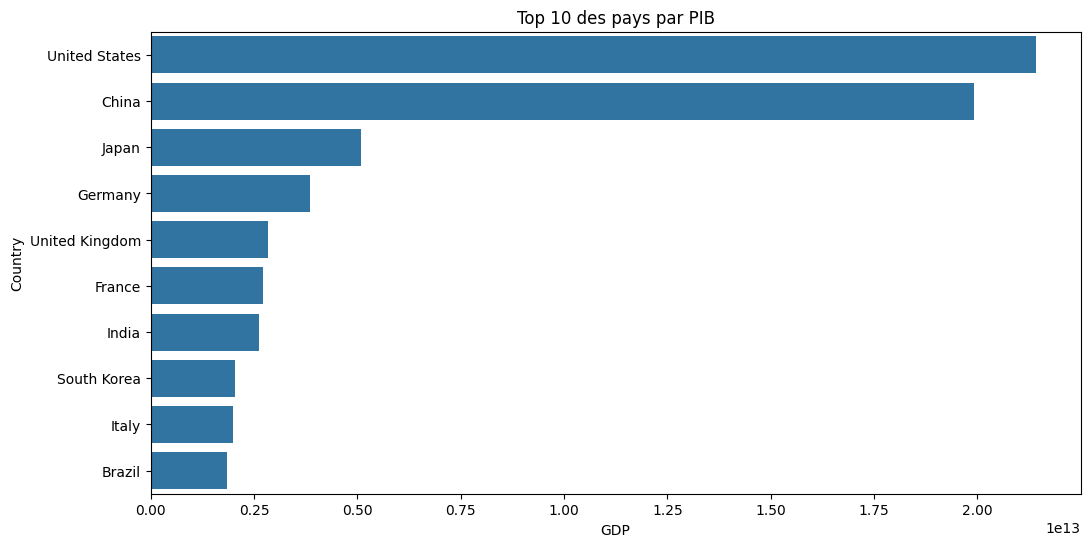

In [230]:
top10 = df_clean.sort_values("GDP", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="GDP",
    y="Country"
)

plt.title("Top 10 des pays par PIB")
plt.show()

Top 10 des pays avec le taux de chômage le plus élevé

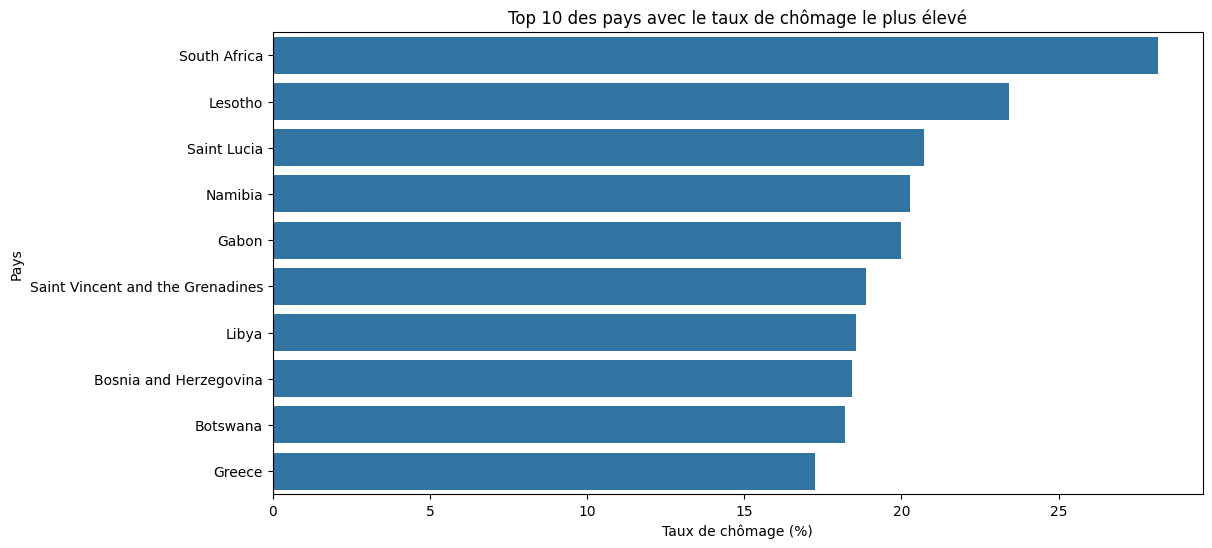

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_chomage = (
    df_clean.sort_values("Unemployment rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_chomage,
    x="Unemployment rate",
    y="Country"
)

plt.title("Top 10 des pays avec le taux de chômage le plus élevé")
plt.xlabel("Taux de chômage (%)")
plt.ylabel("Pays")

plt.show()

Top 10 des pays ayant la plus forte espérance de vie

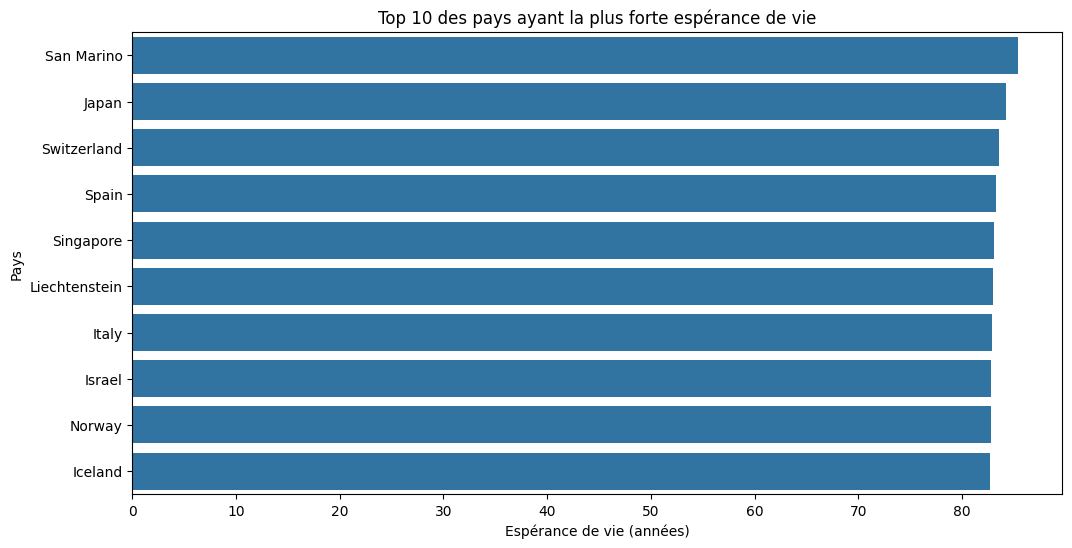

In [233]:
top10_vie = (
    df_clean.sort_values("Life expectancy", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_vie,
    x="Life expectancy",
    y="Country"
)

plt.title("Top 10 des pays ayant la plus forte espérance de vie")
plt.xlabel("Espérance de vie (années)")
plt.ylabel("Pays")

plt.show()

In [234]:
print("Top 10 du taux de chômage")
display(top10_chomage[["Country", "Unemployment rate"]])

print("Top 10 de l'espérance de vie")
display(top10_vie[["Country", "Life expectancy"]])

Top 10 du taux de chômage


,Country,Unemployment rate
161,South Africa,28.18
95,Lesotho,23.41
146,Saint Lucia,20.71
119,Namibia,20.27
61,Gabon,20.00
147,Saint Vincent and the Grenadines,18.88
97,Libya,18.56
21,Bosnia and Herzegovina,18.42
22,Botswana,18.19
66,Greece,17.24


Top 10 de l'espérance de vie


,Country,Life expectancy
149,San Marino,85.4
85,Japan,84.2
169,Switzerland,83.6
164,Spain,83.3
156,Singapore,83.1
98,Liechtenstein,83.0
83,Italy,82.9
82,Israel,82.8
129,Norway,82.8
76,Iceland,82.7


# Conclusion de l'analyse exploratoire

L'analyse exploratoire met en évidence des écarts importants entre les pays en matière de développement économique et social.

Les statistiques descriptives et les visualisations montrent que le PIB, l'espérance de vie, le niveau d'éducation et le taux de chômage sont des indicateurs pertinents pour caractériser le potentiel d'attractivité d'un pays.

Les boxplots ont permis d'identifier plusieurs valeurs extrêmes, notamment pour le PIB et la population. Ces valeurs correspondent à des situations réelles et ont été conservées dans l'analyse.

La matrice de corrélation met également en évidence plusieurs relations entre les variables, notamment entre le PIB, l'espérance de vie et certains indicateurs de santé.

Ces résultats répondent à la problématique formulée dans le cadre de la mission et constituent une base de travail pour une future modélisation prédictive.